In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.impute import KNNImputer
import zipfile
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

In [4]:
import zipfile

zip_path = r"C:\Users\user\Downloads\diabetes_dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    file_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    data = pd.read_csv(z.open(file_name))

print("Data shape:", data.shape)

data.head()


Data shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [19]:
num_cols = data.select_dtypes(include=[np.number]).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns


for col in num_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].mean(), inplace=True)

for col in cat_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].mode()[0], inplace=True)

print("Missing value clearing complete.")
print("Top 10 remaining missing values (should be mostly 0):")
print(data.isna().sum().sort_values(ascending=False).head(10))

Missing value clearing complete.
Top 10 remaining missing values (should be mostly 0):
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
dtype: int64


In [5]:
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

data.replace('?', np.nan, inplace=True)

data['readmitted_target'] = data['readmitted'].apply(lambda x: 1 if x == '>30' else 0)

X = data.drop(['readmitted', 'readmitted_target'], axis=1, errors='ignore')
y = data['readmitted_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

num_imputer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_imputer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_imputer, num_cols),
    ('cat', cat_imputer, cat_cols)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)


In [7]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)
print("Resampled training set shape:", X_train_res.shape, y_train_res.shape)

Resampled training set shape: (105952, 2382) (105952,)


In [9]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_param = {
    'n_estimators': randint(50, 150),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rf_search = RandomizedSearchCV(rf, rf_param, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1)
rf_search.fit(X_train_res, y_train_res)
rf_best = rf_search.best_estimator_
print("Best RF parameters:", rf_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF parameters: {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 136}


In [10]:
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)
xgb_param = {
    'n_estimators': randint(50, 150),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5)
}
xgb_search = RandomizedSearchCV(xgb, xgb_param, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1)
xgb_search.fit(X_train_res, y_train_res)
xgb_best = xgb_search.best_estimator_
print("Best XGB parameters:", xgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB parameters: {'learning_rate': np.float64(0.189597545259111), 'max_depth': 9, 'n_estimators': 132, 'subsample': np.float64(0.5499874579090014)}


In [16]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

svm_fast = LinearSVC(random_state=42, max_iter=5000, class_weight='balanced')
svm_fast.fit(X_train_enc, y_train)

svm_best = svm_fast

y_pred = svm_best.predict(X_test_enc)

print("Linear SVM Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Linear SVM Evaluation
Accuracy: 0.6071042546919524
F1 Score: 0.5187458626707588


=== Linear SVM ===
Accuracy: 0.6574137761619337
F1 Score: 0.1870117756791419
Precision: 0.5463215258855586
Recall: 0.11281474187649458
ROC AUC: 0.6419173564462256


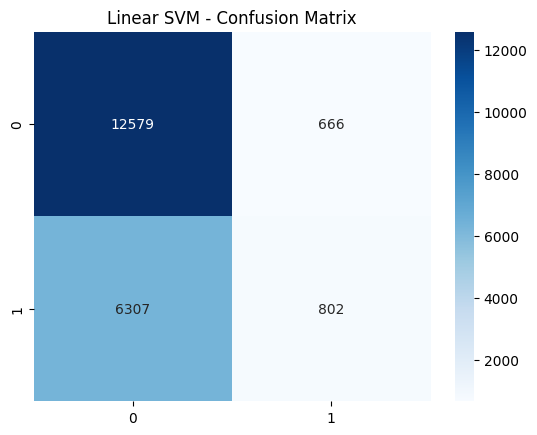

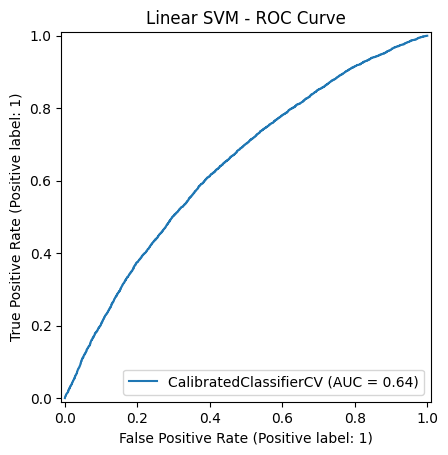

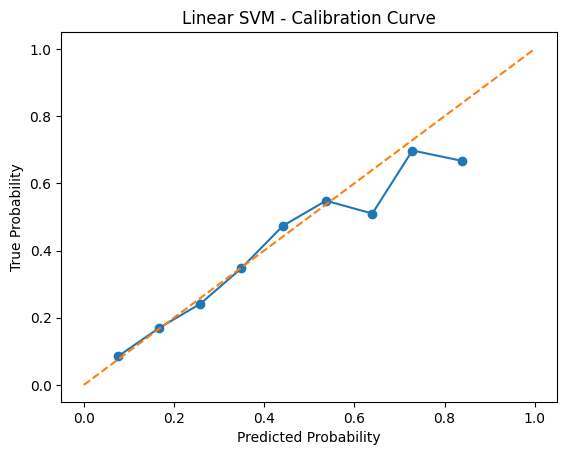

In [20]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Wrap LinearSVC to get probabilities
svm_calibrated = CalibratedClassifierCV(svm_best)  # svm_best = trained LinearSVC
svm_calibrated.fit(X_train_enc, y_train)

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'{name} - ROC Curve')
    plt.show()

    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1], linestyle='--')
    plt.title(f'{name} - Calibration Curve')
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.show()

# ✅ Run evaluation
evaluate_model(svm_calibrated, X_test_enc, y_test, "Linear SVM")



=== Random Forest ===
Accuracy: 0.6399
F1 Score: 0.4898
Precision: 0.4848
Recall: 0.4949
ROC AUC: 0.655940202236214

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.72     13245
           1       0.48      0.49      0.49      7109

    accuracy                           0.64     20354
   macro avg       0.61      0.61      0.61     20354
weighted avg       0.64      0.64      0.64     20354



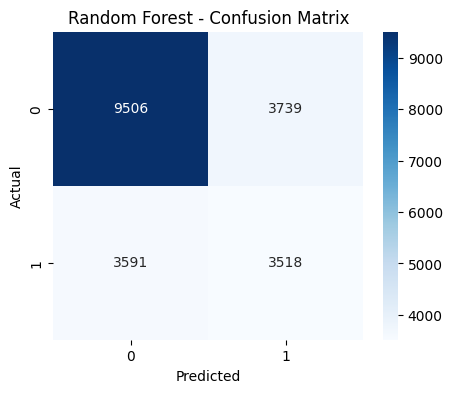


=== XGBoost ===
Accuracy: 0.6734
F1 Score: 0.4143
Precision: 0.5545
Recall: 0.3307
ROC AUC: 0.6959543836122215

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.86      0.77     13245
           1       0.55      0.33      0.41      7109

    accuracy                           0.67     20354
   macro avg       0.63      0.59      0.59     20354
weighted avg       0.65      0.67      0.65     20354



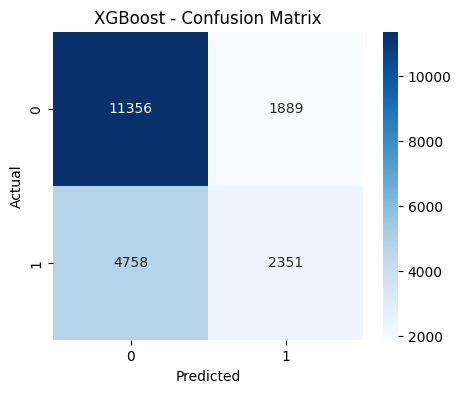

In [36]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, name="Model"):
    # --- Predictions ---
    y_pred = model.predict(X_test)
    
    # --- Probabilities for ROC AUC if available ---
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        y_proba = None
        roc_auc = "N/A"
    
    # --- Print metrics ---
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("ROC AUC:", roc_auc)
    
    # --- Classification report ---
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # --- Confusion matrix plot ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


evaluate_model(rf_best, X_test_enc, y_test, "Random Forest")
evaluate_model(xgb_best, X_test_enc, y_test, "XGBoost")


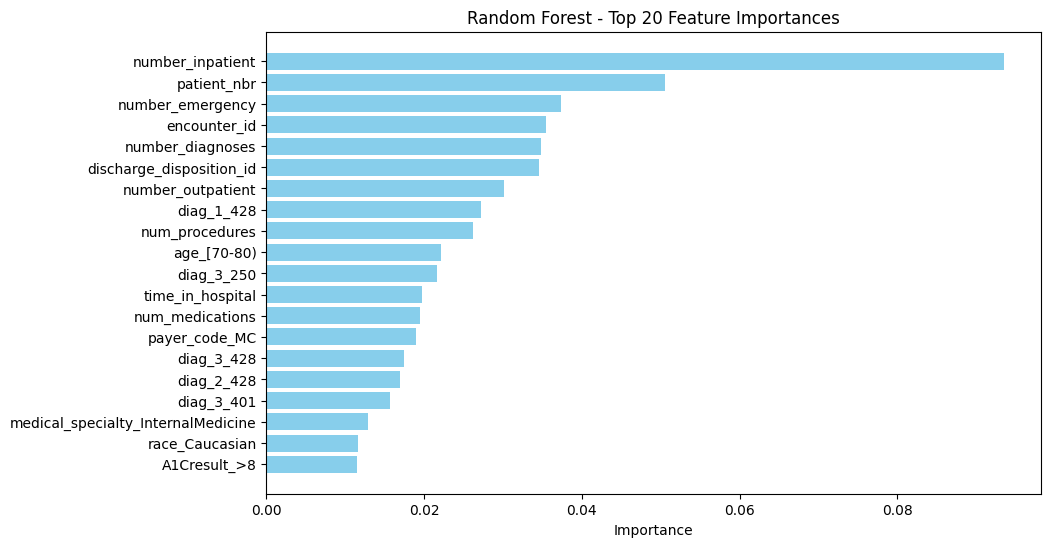

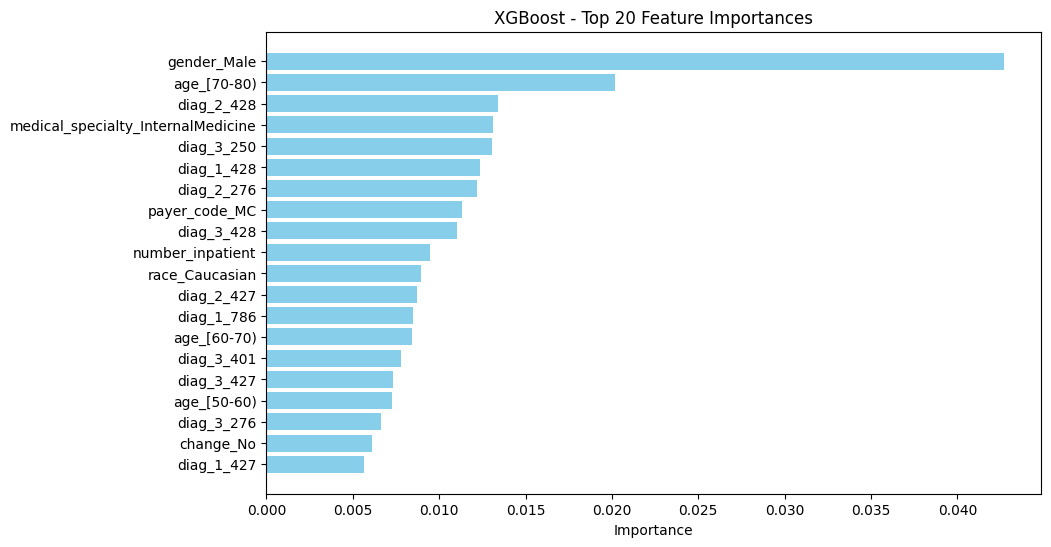

In [29]:
# ✅ Feature Importance Plot for RF/XGB (safe version)
import matplotlib.pyplot as plt
import numpy as np

def get_feature_names(column_transformer):
    """Extract feature names from a ColumnTransformer"""
    feature_names = []
    for name, transformer, columns in column_transformer.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'get_feature_names_out'):
            feature_names.extend(transformer.get_feature_names_out(columns))
        elif isinstance(transformer, list) or transformer is None:
            feature_names.extend(columns)
        else:
            feature_names.extend(columns)
    return feature_names

def plot_feature_importance(model, preprocessor, top=20, name="Model"):
    if not hasattr(model, "feature_importances_"):
        print(f"{name} does not have feature_importances_ attribute.")
        return
    
    importances = model.feature_importances_
    feature_names = get_feature_names(preprocessor)
    
    # Safety: match lengths
    if len(importances) != len(feature_names):
        feature_names = [f"f{i}" for i in range(len(importances))]
    
    indices = np.argsort(importances)[::-1][:top]
    
    plt.figure(figsize=(10,6))
    plt.barh(range(top), importances[indices][::-1], color='skyblue')
    plt.yticks(range(top), np.array(feature_names)[indices][::-1])
    plt.xlabel("Importance")
    plt.title(f"{name} - Top {top} Feature Importances")
    plt.show()

# --- Usage ---
plot_feature_importance(rf_best, preprocessor, top=20, name="Random Forest")
plot_feature_importance(xgb_best, preprocessor, top=20, name="XGBoost")


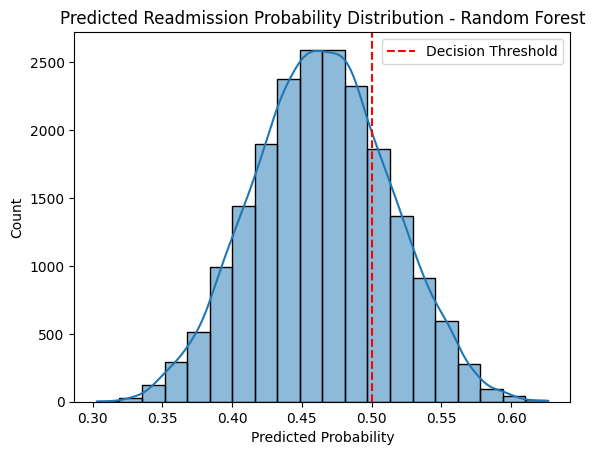

In [ ]:
y_proba_rf = rf_best.predict_proba(X_test_enc)[:,1]
sns.histplot(y_proba_rf, bins=20, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
plt.title("Predicted Readmission Probability Distribution - Random Forest")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()